Barella location calculation by regression.

let p be a point on the xy plane, (-s,0) the location of the source and (d,t) the coordinates of line passing trough (-s,0) and p. the vertical line that passes trough (d,0) is the detector line.

let θ be the angle of rotation of p around the center (s and d are not affected by the rotation) 

given a set of θ_i and t_i I want to find the unrotated p. 

the basic equation is:
$$ t((p_θ)_x + s) = (p_θ)_y(d+s)$$
with p_θ = R(θ)p and R the basic rotation matrix

it is possible to rearrange the equation in the form Ax=y and find x with linear regression:
A_i = (t_i, -(d+s))R(θ_i)
y_i = -t_i s
x = (p_x, p_y)


In [111]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARAMS_FILE = "maria_cristeta.json"
SCAN_INDEX = 0  # imgScan_0

In [112]:
# Build stretcher_measurements.csv from point_a.csv and point_b.csv
with open(PARAMS_FILE) as f:
    _p = json.load(f)["scans"][SCAN_INDEX]
    _angles = _p["angle_eff"]
    _iso_u  = _p["iso_u"]   # per-projection isocenter column (px), measured from detector corner
    _det_columns = _p["det_columns"]

_rows = []
for _label, _path in [("A", "point_a.csv"), ("B", "point_b.csv")]:
    _df = pd.read_csv(_path, sep=r"\s+")
    for _, _row in _df.iterrows():
        _i = int(_row["i"])
        _rows.append({
            "projection_index": _i,
            "angle_deg": round(_angles[_i], 4),
            "x_pixel": _row["X"] - _iso_u[_i]+0.5,   # offset to detector center
            "label": _label,
        })

_out = pd.DataFrame(_rows, columns=["projection_index", "angle_deg", "x_pixel", "label"])
_out = _out.sort_values(["label", "projection_index"]).reset_index(drop=True)
_out.to_csv("stretcher_measurements.csv", index=False)
print(f"Written stretcher_measurements.csv: {len(_out)} rows  (A={(_out.label=='A').sum()}, B={(_out.label=='B').sum()})")

Written stretcher_measurements.csv: 172 rows  (A=78, B=94)


In [113]:
# Load scan parameters
with open(PARAMS_FILE) as f:
    params = json.load(f)

scan = params["scans"][SCAN_INDEX]

angles_deg = np.array(scan["angle_eff"])          # degrees
angles_rad = np.deg2rad(angles_deg)
sod = np.array(scan["sod"])                        # source-to-isocenter distance (mm)
sid = np.array(scan["sid"])                        # source-to-detector distance (mm)
det_col_pitch = scan["det_column_pitch"]           # mm per pixel

n_proj = len(angles_rad)
print(f"Projections: {n_proj}")
print(f"Detector column pitch: {det_col_pitch:.4f} mm")
print(f"SOD mean: {sod.mean():.2f} mm  SID mean: {sid.mean():.2f} mm")

Projections: 480
Detector column pitch: 0.3080 mm
SOD mean: 579.32 mm  SID mean: 986.87 mm


In [114]:
# Load measurements from CSV
# Rows with empty x_pixel or label are skipped automatically.

TABLE_FILE = "stretcher_measurements.csv"

table = pd.read_csv(TABLE_FILE)
table = table.dropna(subset=["x_pixel", "label"])
table["projection_index"] = table["projection_index"].astype(int)

labels = table["label"].unique()
print(f"Loaded {len(table)} measurements — labels: {list(labels)}")
print(table.head(10))

Loaded 172 measurements — labels: ['A', 'B']
   projection_index  angle_deg     x_pixel label
0                45    33.9742 -393.547913     A
1                46    34.7248 -381.552094     A
2                47    35.4755 -369.556458     A
3                48    36.2262 -355.561005     A
4                49    36.9769 -342.898765     A
5                50    37.7276 -328.903679     A
6                51    38.4784 -315.575806     A
7                52    39.2292 -302.914116     A
8                53    39.9800 -290.253609     A
9                54    40.7308 -276.259224     A


In [115]:
# Linear regression per label
def fit_position(subset):
    rows_A, rows_y = [], []
    for _, row in subset.iterrows():
        i  = int(row["projection_index"])
        th = angles_rad[i]
        s  = sod[i]
        d  = sid[i] - sod[i]
        t  = row["x_pixel"] * det_col_pitch  # mm
        R  = np.array([[np.cos(th), -np.sin(th)],
                       [np.sin(th),  np.cos(th)]])
        rows_A.append(np.array([t, -(d + s)]) @ R)
        rows_y.append(-t * s)
    A = np.array(rows_A)
    y = np.array(rows_y)
    x_hat, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return x_hat, A, y

results = {}
for label, subset in table.groupby("label"):
    x_hat, A, y = fit_position(subset)
    results[label] = {"x_hat": x_hat, "A": A, "y": y, "subset": subset}
    print(f"[{label}]  px = {x_hat[0]:.3f} mm,  py = {x_hat[1]:.3f} mm  ({len(subset)} points)")

positions = np.array([r["x_hat"] for r in results.values()])
avg = positions.mean(axis=0)
print(f"\nAverage:  x_c = {avg[0]:.3f} mm,  y_c = {avg[1]:.3f} mm")

stretcher_total_thickness_mm =   38.0   # carbon layer thickness (label 10) [mm]
stretcher_ctrX = (avg[0]+stretcher_total_thickness_mm*0.5)
print(f"Stretcher Center:  X = {avg[1]:.2f} mm,  X = {stretcher_ctrX:.2f} mm")


[A]  px = 150.614 mm,  py = -224.964 mm  (78 points)
[B]  px = 157.675 mm,  py = 208.582 mm  (94 points)

Average:  x_c = 154.145 mm,  y_c = -8.191 mm
Stretcher Center:  X = -8.19 mm,  X = 173.14 mm


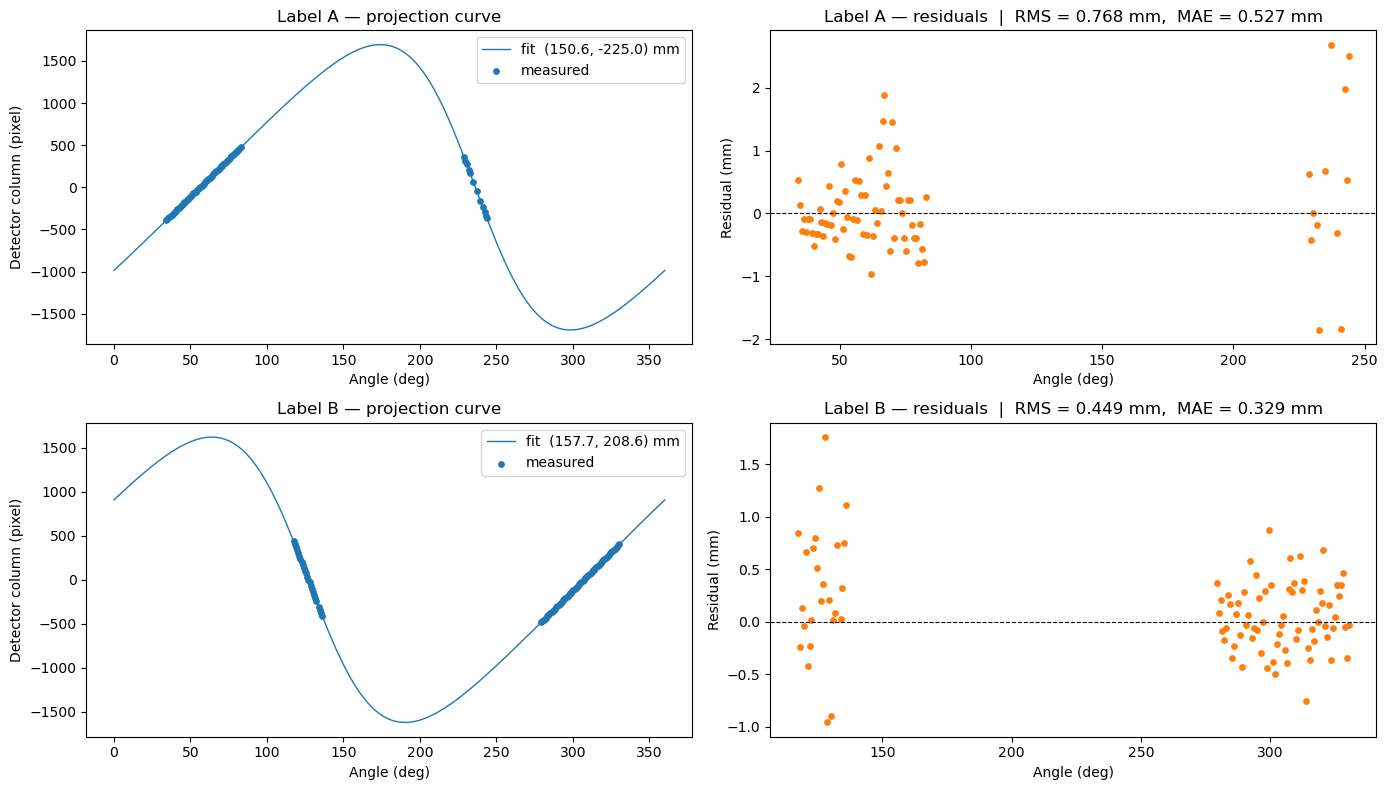

In [116]:
# Theoretical projection curve per label, overlaid with measured data + residuals
plot_angles_deg = np.linspace(0, 360, 1000)
plot_angles_rad = np.deg2rad(plot_angles_deg)

s_mean = sod.mean()
d_mean = sid.mean() - sod.mean()

def project_point(p, th, s, d):
    """Return detector coordinate t (pixels) for point p at angle th."""
    R = np.array([[np.cos(th), -np.sin(th)],
                  [np.sin(th),  np.cos(th)]])
    P_rot = R @ p
    t_mm = P_rot[1] * (d + s) / (P_rot[0] + s)
    return t_mm / det_col_pitch

def projection_curve(p, angles_rad):
    return np.array([project_point(p, th, s_mean, d_mean) for th in angles_rad])

fig, axes = plt.subplots(len(results), 2, figsize=(14, 4 * len(results)), squeeze=False)

for row_axes, (label, r) in zip(axes, results.items()):
    ax_fit, ax_res = row_axes
    p = r["x_hat"]
    t_pixel = projection_curve(p, plot_angles_rad)

    # --- projection curve + measurements ---
    ax_fit.plot(plot_angles_deg, t_pixel, lw=1, label=f"fit  ({p[0]:.1f}, {p[1]:.1f}) mm")
    subset = r["subset"]
    idx = subset["projection_index"].values
    meas_angles_deg = np.rad2deg(angles_rad[idx])
    ax_fit.scatter(meas_angles_deg, subset["x_pixel"].values, s=15, zorder=3, label="measured")
    ax_fit.set_xlabel("Angle (deg)")
    ax_fit.set_ylabel("Detector column (pixel)")
    ax_fit.set_title(f"Label {label} — projection curve")
    ax_fit.legend()

    # --- residuals: measured - predicted at each specific angle ---
    t_pred = np.array([
        project_point(p, angles_rad[i], sod[i], sid[i] - sod[i])
        for i in idx
    ])
    res_px = subset["x_pixel"].values - t_pred
    res_mm = res_px * det_col_pitch

    rms = np.sqrt(np.mean(res_mm**2))
    mae = np.mean(np.abs(res_mm))

    ax_res.scatter(meas_angles_deg, res_mm, s=15, color="C1")
    ax_res.axhline(0, color="k", lw=0.8, ls="--")
    ax_res.set_xlabel("Angle (deg)")
    ax_res.set_ylabel("Residual (mm)")
    ax_res.set_title(f"Label {label} — residuals  |  RMS = {rms:.3f} mm,  MAE = {mae:.3f} mm")

plt.tight_layout()
plt.show()

In [117]:
# Find θ such that p_A and p_B have the same rotated x-coordinate.
#
# (R(θ) p_A)_x = (R(θ) p_B)_x
#   a_x*cos(θ) - a_y*sin(θ) = b_x*cos(θ) - b_y*sin(θ)
#   (a_x - b_x)*cos(θ) = (a_y - b_y)*sin(θ)
#   tan(θ) = (a_x - b_x) / (a_y - b_y)

p_A = results["A"]["x_hat"]
p_B = results["B"]["x_hat"]
ax, ay = p_A
bx, by = p_B

theta_1 = np.arctan2(ax - bx, ay - by)           # principal solution
theta_2 = theta_1 + np.pi                         # second solution (±π apart)
theta_solutions = np.array([theta_1, theta_2]) % (2 * np.pi)

print(f"tan(θ) = ({ax - bx:.4f}) / ({ay - by:.4f}) = {(ax - bx)/(ay - by):.6f}")
print()
for th in sorted(theta_solutions):
    R = np.array([[np.cos(th), -np.sin(th)],
                  [np.sin(th),  np.cos(th)]])
    xA = (R @ p_A)[0]
    xB = (R @ p_B)[0]
    print(f"θ = {np.rad2deg(th):7.3f}°   (Rp_A)_x = {xA:+.4f} mm   (Rp_B)_x = {xB:+.4f} mm   Δ = {xA-xB:.2e} mm")

tan(θ) = (-7.0605) / (-433.5461) = 0.016285

θ =   0.933°   (Rp_A)_x = +154.2575 mm   (Rp_B)_x = +154.2575 mm   Δ = 0.00e+00 mm
θ = 180.933°   (Rp_A)_x = -154.2575 mm   (Rp_B)_x = -154.2575 mm   Δ = 5.68e-14 mm
